# Derive spatial and absolute radiometric calibration coefficients — windowed/OOM-safe

This revised notebook follows the same successful design used in
`extract_polygon_pixel_spectra_radiometry_clean (1).ipynb`:

- read only the raster windows needed for the current feature or block;
- keep DLS and NoDLS as separate cases;
- retain all 11 source bands, with source band 5 identified as PAN;
- use robust summaries and feature/patch-cluster bootstrap uncertainty;
- save intermediate extraction and QA/QC products.

It does **not** allocate the complete Westham–Brunswick overlap as two
11-band arrays. The overlap is inspected in bounded raster blocks.

Outputs:

1. Automatic Brunswick-to-Westham registration shift by date and DLS mode.
2. Homogeneous overlap-patch tables.
3. Bandwise spatial transforms, Brunswick → Westham.
4. May 18 Westham black/grey-panel imagery spectra.
5. Recomputed absolute calibration coefficients for DLS and NoDLS.
6. Comparison with the legacy absolute coefficients.

Transform convention:

\[
y = g x + b
\]

## 1. Imports and plotting setup

In [1]:
print('Start')

Start


In [2]:
from pathlib import Path
import gc
import json
import os
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import seaborn as sns

from affine import Affine
from IPython.display import display
from rasterio.enums import Resampling
from rasterio.features import geometry_mask, geometry_window
from rasterio.vrt import WarpedVRT
from rasterio.windows import Window, from_bounds
from shapely.geometry import box, mapping
from sklearn.linear_model import HuberRegressor, LinearRegression
from sklearn.metrics import r2_score

try:
    from skimage.registration import phase_cross_correlation
    HAVE_SKIMAGE_REGISTRATION = True
except ImportError:
    HAVE_SKIMAGE_REGISTRATION = False

plt.style.use("default")
%config InlineBackend.figure_format = "retina"
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 250)
pd.set_option("display.max_rows", 250)

## 2. Project and Azure/container configuration

In [3]:
def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() or (candidate / "src").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
print("Project root:", PROJECT_ROOT)

STORAGE_ACCOUNT_NAME = "geoanalytics"
CONTAINER_NAME = "wesa-fup-restricted-027817p"
USE_AZURE_CONTAINER = True

if USE_AZURE_CONTAINER:
    try:
        import hatfield_funcs as hf

        hf.config.configure_azure()
        hf.config.configure_data_root_path(CONTAINER_NAME)

        os.environ.setdefault(
            "AZURE_STORAGE_ACCOUNT",
            STORAGE_ACCOUNT_NAME,
        )
        os.environ.setdefault("GDAL_AZURE_USE_MSI", "YES")
        os.environ.setdefault("GDAL_CACHEMAX", "512")
    except ImportError:
        warnings.warn(
            "hatfield_funcs is unavailable. Azure access must already "
            "be configured."
        )


def container_path(path, container_name=CONTAINER_NAME):
    normalized = str(path).replace("\\", "/").lstrip("/")
    if USE_AZURE_CONTAINER:
        return f"/vsiaz/{container_name}/{normalized}"
    return str(PROJECT_ROOT / normalized)

Project root: /home/coder/jchampion/Biofilm_LEG13553/confidential-leg13553-biofilm


## 3. Analysis parameters and band definitions

In [4]:
DATES = ["2026-05-04", "2026-05-18"]
DLS_MODES = ["DLS", "NoDLS"]

ALL_TOUCHED = False
ASSUMED_RASTER_CRS = None
APPLY_NONDEFAULT_SCALE_OFFSET = True

SAVE_OUTPUTS = True
OVERWRITE_OUTPUTS = True

OUTPUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "imagery"
    / "radiometry_eval"
    / "spatial_absolute_calibration"
)

SOURCE_BAND_NUMBERS = list(range(1, 12))
SOURCE_BAND_NAMES = [
    "B1", "B2", "B3", "B4", "PAN",
    "B5", "B6", "B7", "B8", "B9", "B10",
]
SPECTRAL_WAVELENGTHS_NM = {
    "B1": 444,
    "B2": 475,
    "B3": 531,
    "B4": 560,
    "B5": 650,
    "B6": 668,
    "B7": 705,
    "B8": 717,
    "B9": 740,
    "B10": 842,
}
SPECTRAL_BAND_NAMES = list(SPECTRAL_WAVELENGTHS_NM)

BAND_METADATA = pd.DataFrame({
    "source_band": SOURCE_BAND_NUMBERS,
    "band_name": SOURCE_BAND_NAMES,
})
BAND_METADATA["wavelength_nm"] = (
    BAND_METADATA["band_name"].map(SPECTRAL_WAVELENGTHS_NM)
)
BAND_METADATA["is_pan"] = BAND_METADATA["band_name"].eq("PAN")

# Registration is performed from a directly downsampled single-band read.
REGISTRATION_BAND_NAME = "B4"
REGISTRATION_MAX_PIXELS = 1200
REGISTRATION_UPSAMPLE_FACTOR = 20
REGISTRATION_MAX_ABS_SHIFT_PIXELS = 20

# Overlap is processed block by block.
READ_BLOCK_SIZE_PIXELS = 512
PATCH_SIZE_PIXELS = 32
PATCH_STRIDE_PIXELS = 32
MIN_VALID_FRACTION = 0.95
MAX_ROBUST_CV = 0.10
MAX_NORMALIZED_GRADIENT = 0.08
MAX_PATCHES_PER_CASE = 500
N_INTENSITY_BINS = 10
MAX_PATCHES_PER_INTENSITY_BIN = 50

SPATIAL_FIT_METHOD = "huber"
MIN_PATCHES_PER_BAND = 12
N_BOOTSTRAP = 1000
RANDOM_SEED = 872341

ABSOLUTE_DATE = "2026-05-18"
PANEL_NAMES = ["black", "grey"]

# Set this explicitly if automatic discovery finds zero or multiple files.
PANEL_REFERENCE_TABLE = None

LEGACY_ABSOLUTE = pd.DataFrame({
    "band_name": [f"B{i}" for i in range(1, 11)],
    "wavelength_nm": [
        444, 475, 531, 560, 650,
        668, 705, 717, 740, 842,
    ],
    "gain": [
        1.721, 1.621, 1.246, 1.305, 1.137,
        1.114, 1.157, 1.153, 1.187, 1.210,
    ],
    "offset": [
        -0.053, -0.045, -0.029, -0.029, -0.023,
        -0.020, -0.030, -0.028, -0.040, -0.051,
    ],
})

display(BAND_METADATA)

,source_band,band_name,wavelength_nm,is_pan
0,1,B1,444.0,False
1,2,B2,475.0,False
2,3,B3,531.0,False
3,4,B4,560.0,False
4,5,PAN,NaN,True
5,6,B5,650.0,False
6,7,B6,668.0,False
7,8,B7,705.0,False
8,9,B8,717.0,False
9,10,B9,740.0,False


## 4. Input paths

In [5]:
POLYGON_RELATIVE_PATHS = {
    "westham": Path(
        "data/processed/imagery/radiometry_eval/"
        "spectrally_constant_features_westham_v2.geojson"
    ),
    "brunswick": Path(
        "data/processed/imagery/radiometry_eval/"
        "spectrally_constant_features_brunswick_v2.geojson"
    ),
}

RASTER_RELATIVE_PATHS = {
    ("2026-05-04", "brunswick", "DLS"): Path(
        "airborne_data_20260504_v2_COG/"
        "RTB2_10Band_Brunswick_20260504_DLS_v2.tif"
    ),
    ("2026-05-04", "brunswick", "NoDLS"): Path(
        "airborne_data_20260504_v2_COG/"
        "RTB2_10Band_Brunswick_20260504_NoDLS_v2.tif"
    ),
    ("2026-05-04", "westham", "DLS"): Path(
        "airborne_data_20260504_v2_COG/"
        "RTB2_10Band_Westham_20260504_DLS_v2.tif"
    ),
    ("2026-05-04", "westham", "NoDLS"): Path(
        "airborne_data_20260504_v2_COG/"
        "RTB2_10Band_Westham_20260504_NoDLS_v2.tif"
    ),
    ("2026-05-18", "brunswick", "DLS"): Path(
        "airborne_data_20260518_v2_COG/"
        "RTB2_10Band_Brunswick_20260518_DLS_v2.tif"
    ),
    ("2026-05-18", "brunswick", "NoDLS"): Path(
        "airborne_data_20260518_v2_COG/"
        "RTB2_10Band_Brunswick_20260518_NoDLS_v2.tif"
    ),
    ("2026-05-18", "westham", "DLS"): Path(
        "airborne_data_20260518_v2_COG/"
        "RTB2_10Band_Westham_20260518_DLS_v2.tif"
    ),
    ("2026-05-18", "westham", "NoDLS"): Path(
        "airborne_data_20260518_v2_COG/"
        "RTB2_10Band_Westham_20260518_NoDLS_v2.tif"
    ),
}

POLYGON_PATHS = {
    site: container_path(path)
    for site, path in POLYGON_RELATIVE_PATHS.items()
}
RASTER_PATHS = {
    key: container_path(path)
    for key, path in RASTER_RELATIVE_PATHS.items()
}

input_registry = pd.DataFrame([
    {
        "flight_date": date,
        "site": site,
        "dls_mode": mode,
        "raster_path": path,
    }
    for (date, site, mode), path in RASTER_PATHS.items()
]).sort_values(["flight_date", "site", "dls_mode"])

display(input_registry)

,flight_date,site,dls_mode,raster_path
0,2026-05-04,brunswick,DLS,/vsiaz/wesa-fup-restricted-027817p/airborne_da...
1,2026-05-04,brunswick,NoDLS,/vsiaz/wesa-fup-restricted-027817p/airborne_da...
2,2026-05-04,westham,DLS,/vsiaz/wesa-fup-restricted-027817p/airborne_da...
3,2026-05-04,westham,NoDLS,/vsiaz/wesa-fup-restricted-027817p/airborne_da...
4,2026-05-18,brunswick,DLS,/vsiaz/wesa-fup-restricted-027817p/airborne_da...
5,2026-05-18,brunswick,NoDLS,/vsiaz/wesa-fup-restricted-027817p/airborne_da...
6,2026-05-18,westham,DLS,/vsiaz/wesa-fup-restricted-027817p/airborne_da...
7,2026-05-18,westham,NoDLS,/vsiaz/wesa-fup-restricted-027817p/airborne_da...


## 5. Windowed raster utilities

This uses the same central idea as the recent temporal notebook:
`geometry_window` or bounded `Window` reads rather than full-raster arrays.
Raster values are kept as `float32` while they are in memory.

In [6]:
def extraction_crs(src):
    if ASSUMED_RASTER_CRS is not None:
        return ASSUMED_RASTER_CRS
    if src.crs is None:
        raise ValueError(
            "Raster has no CRS and ASSUMED_RASTER_CRS is None."
        )
    return src.crs


def read_scaled32(
    src,
    indexes,
    *,
    window=None,
    out_shape=None,
    resampling=Resampling.nearest,
):
    data = src.read(
        indexes=indexes,
        window=window,
        out_shape=out_shape,
        masked=True,
        resampling=resampling,
    )
    values = np.ma.getdata(data).astype("float32", copy=False)
    mask = np.ma.getmaskarray(data)

    scales = np.asarray(src.scales, dtype="float32")[
        np.asarray(indexes) - 1
    ]
    offsets = np.asarray(src.offsets, dtype="float32")[
        np.asarray(indexes) - 1
    ]

    if APPLY_NONDEFAULT_SCALE_OFFSET and (
        not np.allclose(scales, 1)
        or not np.allclose(offsets, 0)
    ):
        values = (
            values * scales[:, None, None]
            + offsets[:, None, None]
        )

    values[mask] = np.nan
    return values


def overlap_bounds(a, b):
    bounds = rasterio.coords.BoundingBox(
        max(a.left, b.left),
        max(a.bottom, b.bottom),
        min(a.right, b.right),
        min(a.top, b.top),
    )
    if (
        bounds.left >= bounds.right
        or bounds.bottom >= bounds.top
    ):
        raise ValueError("The two rasters have no overlap.")
    return bounds


def overlap_grid(west, br):
    bounds = overlap_bounds(west.bounds, br.bounds)
    window = (
        from_bounds(*bounds, transform=west.transform)
        .round_offsets()
        .round_lengths()
        .intersection(
            Window(0, 0, west.width, west.height)
        )
    )
    return {
        "bounds": bounds,
        "west_window": window,
        "transform": west.window_transform(window),
        "height": int(window.height),
        "width": int(window.width),
        "crs": extraction_crs(west),
    }


def robust_sigma(values, axis=None):
    values = np.asarray(values, dtype=float)
    median = np.nanmedian(
        values,
        axis=axis,
        keepdims=True,
    )
    return 1.4826 * np.nanmedian(
        np.abs(values - median),
        axis=axis,
    )


def normalized_gradient(image):
    gy, gx = np.gradient(image)
    magnitude = np.sqrt(gx * gx + gy * gy)
    return np.nanmedian(magnitude) / max(
        np.nanmedian(np.abs(image)),
        1e-9,
    )


def gradient_image(image):
    gy, gx = np.gradient(image)
    return np.sqrt(gx * gx + gy * gy)

## 6. Memory-safe automatic shift estimation

In [7]:
def brute_force_shift(reference, moving, max_shift):
    best = None
    for row_shift in range(-max_shift, max_shift + 1):
        for col_shift in range(-max_shift, max_shift + 1):
            row0 = max(0, row_shift)
            row1 = min(
                reference.shape[0],
                moving.shape[0] + row_shift,
            )
            col0 = max(0, col_shift)
            col1 = min(
                reference.shape[1],
                moving.shape[1] + col_shift,
            )
            if row1-row0 < 32 or col1-col0 < 32:
                continue

            ref = reference[row0:row1, col0:col1]
            mov = moving[
                row0-row_shift:row1-row_shift,
                col0-col_shift:col1-col_shift,
            ]
            valid = np.isfinite(ref) & np.isfinite(mov)
            if valid.sum() < 1000:
                continue

            x = ref[valid].astype(float)
            y = mov[valid].astype(float)
            x -= x.mean()
            y -= y.mean()
            denominator = np.sqrt(
                np.sum(x*x) * np.sum(y*y)
            )
            score = (
                np.sum(x*y) / denominator
                if denominator > 0 else -np.inf
            )

            if best is None or score > best["score"]:
                best = {
                    "row": row_shift,
                    "col": col_shift,
                    "score": score,
                }
    if best is None:
        raise RuntimeError(
            "Fallback registration could not estimate a shift."
        )
    return best


def estimate_shift(west_path, brunswick_path):
    registration_band = int(
        BAND_METADATA.loc[
            BAND_METADATA["band_name"].eq(
                REGISTRATION_BAND_NAME
            ),
            "source_band",
        ].iloc[0]
    )

    with rasterio.open(west_path) as west, rasterio.open(
        brunswick_path
    ) as br:
        grid = overlap_grid(west, br)

        scale = max(
            grid["height"],
            grid["width"],
        ) / REGISTRATION_MAX_PIXELS
        scale = max(scale, 1.0)

        out_height = max(
            64,
            int(np.ceil(grid["height"] / scale)),
        )
        out_width = max(
            64,
            int(np.ceil(grid["width"] / scale)),
        )

        reference = read_scaled32(
            west,
            [registration_band],
            window=grid["west_window"],
            out_shape=(1, out_height, out_width),
            resampling=Resampling.bilinear,
        )[0]

        coarse_transform = (
            grid["transform"]
            * Affine.scale(
                grid["width"] / out_width,
                grid["height"] / out_height,
            )
        )

        with WarpedVRT(
            br,
            crs=grid["crs"],
            transform=coarse_transform,
            width=out_width,
            height=out_height,
            resampling=Resampling.bilinear,
        ) as vrt:
            moving = read_scaled32(
                vrt,
                [registration_band],
            )[0]

    reference = gradient_image(reference)
    moving = gradient_image(moving)

    valid = (
        np.isfinite(reference)
        & np.isfinite(moving)
    )
    if valid.sum() < 1000:
        raise RuntimeError(
            "Too few valid coarse pixels for registration."
        )

    reference = np.where(
        valid,
        reference,
        np.nanmedian(reference[valid]),
    )
    moving = np.where(
        valid,
        moving,
        np.nanmedian(moving[valid]),
    )

    row_factor = grid["height"] / out_height
    col_factor = grid["width"] / out_width

    if HAVE_SKIMAGE_REGISTRATION:
        shift, error, _ = phase_cross_correlation(
            reference,
            moving,
            upsample_factor=REGISTRATION_UPSAMPLE_FACTOR,
            normalization="phase",
        )
        result = {
            "row_shift_pixels": float(
                shift[0] * row_factor
            ),
            "col_shift_pixels": float(
                shift[1] * col_factor
            ),
            "registration_error": float(error),
            "method": "coarse_phase_cross_correlation",
            "registration_shape": (
                out_height,
                out_width,
            ),
        }
    else:
        max_coarse_shift = max(
            1,
            int(np.ceil(
                REGISTRATION_MAX_ABS_SHIFT_PIXELS
                / max(row_factor, col_factor)
            )),
        )
        estimate = brute_force_shift(
            reference,
            moving,
            max_coarse_shift,
        )
        result = {
            "row_shift_pixels": float(
                estimate["row"] * row_factor
            ),
            "col_shift_pixels": float(
                estimate["col"] * col_factor
            ),
            "registration_error": float(
                1 - estimate["score"]
            ),
            "method": "coarse_brute_force_ncc",
            "registration_shape": (
                out_height,
                out_width,
            ),
        }

    del reference, moving
    gc.collect()
    return result

## 7. Block-streamed homogeneous overlap patches

In [8]:
def evaluate_patch(
    west_patch,
    brunswick_patch,
    *,
    global_row,
    global_col,
    overlap_transform,
):
    common_valid = (
        np.isfinite(west_patch).all(axis=0)
        & np.isfinite(brunswick_patch).all(axis=0)
    )

    valid_fraction = common_valid.mean()
    if valid_fraction < MIN_VALID_FRACTION:
        return None

    west_values = west_patch[:, common_valid]
    brunswick_values = brunswick_patch[:, common_valid]

    west_median = np.nanmedian(
        west_values,
        axis=1,
    )
    brunswick_median = np.nanmedian(
        brunswick_values,
        axis=1,
    )
    west_sigma = robust_sigma(
        west_values,
        axis=1,
    )
    brunswick_sigma = robust_sigma(
        brunswick_values,
        axis=1,
    )

    west_cv = np.nanmedian(
        west_sigma
        / np.maximum(
            np.abs(west_median),
            1e-9,
        )
    )
    brunswick_cv = np.nanmedian(
        brunswick_sigma
        / np.maximum(
            np.abs(brunswick_median),
            1e-9,
        )
    )

    spectral_indexes = (
        BAND_METADATA.loc[
            ~BAND_METADATA["is_pan"],
            "source_band",
        ].to_numpy()
        - 1
    )

    west_composite = np.full(
        common_valid.shape,
        np.nan,
        dtype=np.float32,
    )
    brunswick_composite = np.full(
        common_valid.shape,
        np.nan,
        dtype=np.float32,
    )

    west_composite[common_valid] = np.mean(
        west_patch[spectral_indexes][:, common_valid],
        axis=0,
    )
    brunswick_composite[common_valid] = np.mean(
        brunswick_patch[spectral_indexes][:, common_valid],
        axis=0,
    )

    gradient_score = max(
        normalized_gradient(
            np.where(
                common_valid,
                west_composite,
                np.nan,
            )
        ),
        normalized_gradient(
            np.where(
                common_valid,
                brunswick_composite,
                np.nan,
            )
        ),
    )

    if (
        west_cv > MAX_ROBUST_CV
        or brunswick_cv > MAX_ROBUST_CV
        or gradient_score > MAX_NORMALIZED_GRADIENT
    ):
        return None

    patch_window = Window(
        global_col,
        global_row,
        PATCH_SIZE_PIXELS,
        PATCH_SIZE_PIXELS,
    )
    patch_transform = rasterio.windows.transform(
        patch_window,
        overlap_transform,
    )

    left, top = rasterio.transform.xy(
        patch_transform,
        0,
        0,
        offset="ul",
    )
    right, bottom = rasterio.transform.xy(
        patch_transform,
        PATCH_SIZE_PIXELS,
        PATCH_SIZE_PIXELS,
        offset="ul",
    )

    record = {
        "row_off": global_row,
        "col_off": global_col,
        "valid_fraction": float(valid_fraction),
        "west_robust_cv": float(west_cv),
        "brunswick_robust_cv": float(
            brunswick_cv
        ),
        "gradient_score": float(gradient_score),
        "homogeneity_score": float(
            max(west_cv, brunswick_cv)
            + gradient_score
        ),
        "geometry": box(
            min(left, right),
            min(bottom, top),
            max(left, right),
            max(bottom, top),
        ),
    }

    for index, band_name in enumerate(
        SOURCE_BAND_NAMES
    ):
        record[
            f"west_{band_name}_median"
        ] = west_median[index]
        record[
            f"br_{band_name}_median"
        ] = brunswick_median[index]
        record[
            f"west_{band_name}_sigma"
        ] = west_sigma[index]
        record[
            f"br_{band_name}_sigma"
        ] = brunswick_sigma[index]

    return record


def select_homogeneous_patches(
    west_path,
    brunswick_path,
    *,
    shift=(0.0, 0.0),
):
    records = []

    with rasterio.open(west_path) as west, rasterio.open(
        brunswick_path
    ) as br:
        grid = overlap_grid(west, br)
        overlap_crs = grid["crs"]

        row_shift, col_shift = shift
        shifted_brunswick_transform = (
            Affine.translation(
                col_shift * abs(west.transform.a),
                -row_shift * abs(west.transform.e),
            )
            * br.transform
        )

        with WarpedVRT(
            br,
            crs=grid["crs"],
            transform=grid["transform"],
            width=grid["width"],
            height=grid["height"],
            resampling=Resampling.bilinear,
            src_transform=shifted_brunswick_transform,
        ) as vrt:
            total_block_rows = int(
                np.ceil(
                    grid["height"]
                    / READ_BLOCK_SIZE_PIXELS
                )
            )
            total_block_cols = int(
                np.ceil(
                    grid["width"]
                    / READ_BLOCK_SIZE_PIXELS
                )
            )

            for block_row_index, block_row in enumerate(
                range(
                    0,
                    grid["height"],
                    READ_BLOCK_SIZE_PIXELS,
                )
            ):
                block_height = min(
                    READ_BLOCK_SIZE_PIXELS,
                    grid["height"] - block_row,
                )
                if block_height < PATCH_SIZE_PIXELS:
                    continue

                print(
                    f"  block row "
                    f"{block_row_index + 1}/"
                    f"{total_block_rows}"
                )

                for block_col in range(
                    0,
                    grid["width"],
                    READ_BLOCK_SIZE_PIXELS,
                ):
                    block_width = min(
                        READ_BLOCK_SIZE_PIXELS,
                        grid["width"] - block_col,
                    )
                    if block_width < PATCH_SIZE_PIXELS:
                        continue

                    vrt_block_window = Window(
                        block_col,
                        block_row,
                        block_width,
                        block_height,
                    )
                    west_block_window = Window(
                        (
                            grid["west_window"].col_off
                            + block_col
                        ),
                        (
                            grid["west_window"].row_off
                            + block_row
                        ),
                        block_width,
                        block_height,
                    )

                    west_block = read_scaled32(
                        west,
                        SOURCE_BAND_NUMBERS,
                        window=west_block_window,
                    )
                    brunswick_block = read_scaled32(
                        vrt,
                        SOURCE_BAND_NUMBERS,
                        window=vrt_block_window,
                    )

                    for local_row in range(
                        0,
                        (
                            block_height
                            - PATCH_SIZE_PIXELS
                            + 1
                        ),
                        PATCH_STRIDE_PIXELS,
                    ):
                        for local_col in range(
                            0,
                            (
                                block_width
                                - PATCH_SIZE_PIXELS
                                + 1
                            ),
                            PATCH_STRIDE_PIXELS,
                        ):
                            west_patch = west_block[
                                :,
                                local_row:
                                local_row
                                + PATCH_SIZE_PIXELS,
                                local_col:
                                local_col
                                + PATCH_SIZE_PIXELS,
                            ]
                            brunswick_patch = (
                                brunswick_block[
                                    :,
                                    local_row:
                                    local_row
                                    + PATCH_SIZE_PIXELS,
                                    local_col:
                                    local_col
                                    + PATCH_SIZE_PIXELS,
                                ]
                            )

                            record = evaluate_patch(
                                west_patch,
                                brunswick_patch,
                                global_row=(
                                    block_row
                                    + local_row
                                ),
                                global_col=(
                                    block_col
                                    + local_col
                                ),
                                overlap_transform=(
                                    grid["transform"]
                                ),
                            )
                            if record is not None:
                                records.append(record)

                    del west_block
                    del brunswick_block
                    gc.collect()

    patches = gpd.GeoDataFrame(
        records,
        geometry="geometry",
        crs=overlap_crs,
    )

    if patches.empty:
        raise RuntimeError(
            "No homogeneous overlap patches passed "
            "the configured thresholds."
        )

    intensity = patches[
        [
            f"west_{band_name}_median"
            for band_name in SPECTRAL_BAND_NAMES
        ]
    ].median(axis=1)

    patches["intensity_bin"] = pd.qcut(
        intensity.rank(method="first"),
        q=min(
            N_INTENSITY_BINS,
            len(patches),
        ),
        labels=False,
        duplicates="drop",
    )

    return (
        patches.sort_values(
            "homogeneity_score"
        )
        .groupby(
            "intensity_bin",
            group_keys=False,
        )
        .head(
            MAX_PATCHES_PER_INTENSITY_BIN
        )
        .sort_values(
            "homogeneity_score"
        )
        .head(
            MAX_PATCHES_PER_CASE
        )
        .copy()
    )

## 8. Spatial transform fitting and patch-cluster bootstrap

In [9]:
def fit_linear_transform(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < MIN_PATCHES_PER_BAND:
        raise ValueError(
            f"Only {len(x)} valid patches."
        )

    if SPATIAL_FIT_METHOD == "huber":
        model = HuberRegressor(
            epsilon=1.35,
            alpha=0.0,
            max_iter=1000,
        )
    elif SPATIAL_FIT_METHOD == "ols":
        model = LinearRegression()
    else:
        raise ValueError(
            f"Unknown fit method: "
            f"{SPATIAL_FIT_METHOD}"
        )

    model.fit(x[:, None], y)
    predicted = model.predict(x[:, None])
    residual = y - predicted

    return {
        "gain": float(model.coef_[0]),
        "offset": float(model.intercept_),
        "r2": float(
            r2_score(y, predicted)
        ),
        "rmse": float(
            np.sqrt(
                np.mean(residual**2)
            )
        ),
        "mae": float(
            np.mean(
                np.abs(residual)
            )
        ),
        "bias": float(
            np.mean(residual)
        ),
        "n": int(len(x)),
    }


def fit_spatial_coefficients(
    patches,
    *,
    date,
    dls_mode,
):
    rng = np.random.default_rng(
        RANDOM_SEED
    )
    coefficient_records = []
    bootstrap_frames = []

    for band_name in SOURCE_BAND_NAMES:
        x = patches[
            f"br_{band_name}_median"
        ].to_numpy()
        y = patches[
            f"west_{band_name}_median"
        ].to_numpy()

        fit = fit_linear_transform(x, y)

        valid = (
            np.isfinite(x)
            & np.isfinite(y)
        )
        x_valid = x[valid]
        y_valid = y[valid]

        bootstrap_records = []
        for iteration in range(
            N_BOOTSTRAP
        ):
            index = rng.integers(
                0,
                len(x_valid),
                size=len(x_valid),
            )
            try:
                bootstrap_fit = (
                    fit_linear_transform(
                        x_valid[index],
                        y_valid[index],
                    )
                )
            except Exception:
                continue

            bootstrap_records.append({
                "bootstrap_iteration": (
                    iteration
                ),
                "gain": (
                    bootstrap_fit["gain"]
                ),
                "offset": (
                    bootstrap_fit["offset"]
                ),
            })

        bootstrap = pd.DataFrame(
            bootstrap_records
        )
        bootstrap["flight_date"] = date
        bootstrap["dls_mode"] = dls_mode
        bootstrap["band_name"] = band_name
        bootstrap_frames.append(
            bootstrap
        )

        coefficient_records.append({
            "transform_name": (
                f"brunswick_to_westham_"
                f"{date}_{dls_mode}"
            ),
            "source_site": "brunswick",
            "destination_site": "westham",
            "flight_date": date,
            "dls_mode": dls_mode,
            "band_name": band_name,
            "wavelength_nm": (
                SPECTRAL_WAVELENGTHS_NM.get(
                    band_name
                )
            ),
            **fit,
            "gain_se": (
                bootstrap["gain"].std(ddof=1)
            ),
            "offset_se": (
                bootstrap["offset"].std(ddof=1)
            ),
            "gain_ci_low": (
                bootstrap["gain"].quantile(
                    0.025
                )
            ),
            "gain_ci_high": (
                bootstrap["gain"].quantile(
                    0.975
                )
            ),
            "offset_ci_low": (
                bootstrap["offset"].quantile(
                    0.025
                )
            ),
            "offset_ci_high": (
                bootstrap["offset"].quantile(
                    0.975
                )
            ),
        })

    return (
        pd.DataFrame(
            coefficient_records
        ),
        pd.concat(
            bootstrap_frames,
            ignore_index=True,
        ),
    )

## 9. Run or resume spatial calibration

This section uses three checkpoints for every date × DLS case:

1. registration shift;
2. homogeneous overlap patches;
3. spatial coefficients and bootstrap results.

Existing outputs are loaded automatically. A completed case therefore does
not need to be recalculated after restarting the notebook.

### Section 9a — Run and recomputation settings

In [10]:
# ============================================================
# Section 9a: run and resume configuration
# ============================================================

# Normally run all four cases. Completed cases will be loaded.
DATES_TO_RUN = DATES
DLS_MODES_TO_RUN = DLS_MODES

# Leave these empty for a normal resumed run.
#
# Examples:
#
# Recompute only the May 4 DLS coefficient fit:
# FORCE_FIT_CASES = {("2026-05-04", "DLS")}
#
# Re-extract its patches and refit:
# FORCE_PATCH_CASES = {("2026-05-04", "DLS")}
#
# Recompute registration, patches, and fit:
# FORCE_REGISTRATION_CASES = {("2026-05-04", "DLS")}

FORCE_REGISTRATION_CASES = set()
FORCE_PATCH_CASES = set()
FORCE_FIT_CASES = set()

if not SAVE_OUTPUTS:
    raise ValueError(
        "SAVE_OUTPUTS must be True for the checkpointed Section 9 workflow."
    )

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

expected_cases = {(date, dls_mode) for date in DATES for dls_mode in DLS_MODES}

requested_cases = {
    (date, dls_mode) for date in DATES_TO_RUN for dls_mode in DLS_MODES_TO_RUN
}

print("Requested cases:")
for case in sorted(requested_cases):
    print(" -", case)

if FORCE_REGISTRATION_CASES:
    print(
        "\nForcing registration, patch extraction, and fit:",
        sorted(FORCE_REGISTRATION_CASES),
    )

if FORCE_PATCH_CASES:
    print(
        "\nForcing patch extraction and fit:",
        sorted(FORCE_PATCH_CASES),
    )

if FORCE_FIT_CASES:
    print(
        "\nForcing coefficient fit only:",
        sorted(FORCE_FIT_CASES),
    )


Requested cases:
 - ('2026-05-04', 'DLS')
 - ('2026-05-04', 'NoDLS')
 - ('2026-05-18', 'DLS')
 - ('2026-05-18', 'NoDLS')


### Section 9b — Checkpoint path and loading functions

In [11]:
# ============================================================
# Section 9b: checkpoint utility functions
# ============================================================


def spatial_case_stem(date, dls_mode):
    return f"{date}_{dls_mode}".replace("-", "")


def spatial_case_paths(date, dls_mode):
    stem = spatial_case_stem(date, dls_mode)

    return {
        "registration": (OUTPUT_DIR / f"{stem}_registration.csv"),
        "patches": (OUTPUT_DIR / f"{stem}_homogeneous_overlap_patches.geojson"),
        "coefficients": (OUTPUT_DIR / f"{stem}_spatial_coefficients.csv"),
        "bootstrap": (OUTPUT_DIR / f"{stem}_spatial_bootstrap.parquet"),
    }


def load_saved_registration(path):
    table = pd.read_csv(path)

    if len(table) != 1:
        raise ValueError(
            f"Expected one registration row in {path}, found {len(table)}."
        )

    registration = table.iloc[0].to_dict()

    # Ensure values used for alignment are numeric.
    registration["row_shift_pixels"] = float(registration["row_shift_pixels"])
    registration["col_shift_pixels"] = float(registration["col_shift_pixels"])
    registration["registration_error"] = float(registration["registration_error"])

    return registration


def save_registration(registration, path):
    pd.DataFrame([registration]).to_csv(
        path,
        index=False,
    )


def load_saved_patches(path):
    patches = gpd.read_file(path)

    if patches.empty:
        raise ValueError(f"Saved patch file is empty: {path}")

    return patches


def save_patches(patches, path):
    # GeoPandas may not overwrite an existing GeoJSON cleanly.
    if path.exists():
        path.unlink()

    patches.to_file(
        path,
        driver="GeoJSON",
    )


def spatial_case_status(date, dls_mode):
    paths = spatial_case_paths(
        date,
        dls_mode,
    )

    return {
        "flight_date": date,
        "dls_mode": dls_mode,
        "registration_exists": (paths["registration"].exists()),
        "patches_exist": (paths["patches"].exists()),
        "coefficients_exist": (paths["coefficients"].exists()),
        "bootstrap_exists": (paths["bootstrap"].exists()),
        "case_complete": (
            paths["registration"].exists()
            and paths["patches"].exists()
            and paths["coefficients"].exists()
            and paths["bootstrap"].exists()
        ),
    }


status_before_run = pd.DataFrame(
    [spatial_case_status(date, dls_mode) for date, dls_mode in sorted(expected_cases)]
)

display(status_before_run)


,flight_date,dls_mode,registration_exists,patches_exist,coefficients_exist,bootstrap_exists,case_complete
0,2026-05-04,DLS,True,True,True,True,True
1,2026-05-04,NoDLS,True,True,True,True,True
2,2026-05-18,DLS,True,True,True,True,True
3,2026-05-18,NoDLS,True,True,True,True,True


### Section 9c — Run or resume the requested cases

In [12]:
# ============================================================
# Section 9c: run or resume individual spatial cases
# ============================================================

spatial_tables = []
bootstrap_tables = []
registration_records = []
patch_layers = {}

for date in DATES_TO_RUN:
    for dls_mode in DLS_MODES_TO_RUN:
        case = (date, dls_mode)

        paths = spatial_case_paths(
            date,
            dls_mode,
        )

        west_path = RASTER_PATHS[(date, "westham", dls_mode)]
        brunswick_path = RASTER_PATHS[(date, "brunswick", dls_mode)]

        print("\n" + "=" * 70)
        print(f"Spatial case: {date} | {dls_mode}")
        print("=" * 70)

        force_registration = case in FORCE_REGISTRATION_CASES

        # If registration changes, patches and coefficients must
        # also be recomputed.
        force_patches = case in FORCE_PATCH_CASES or force_registration

        # If patches change, coefficients must be refitted.
        force_fit = case in FORCE_FIT_CASES or force_patches

        # ------------------------------------------------------
        # Checkpoint 1: registration
        # ------------------------------------------------------
        if paths["registration"].exists() and not force_registration:
            registration = load_saved_registration(paths["registration"])

            print(
                "Loaded registration:",
                {
                    "row_shift_pixels": (registration["row_shift_pixels"]),
                    "col_shift_pixels": (registration["col_shift_pixels"]),
                    "registration_error": (registration["registration_error"]),
                    "method": (registration["method"]),
                },
            )
        else:
            print("Computing registration...")

            registration = estimate_shift(
                west_path,
                brunswick_path,
            )

            registration.update(
                {
                    "flight_date": date,
                    "dls_mode": dls_mode,
                }
            )

            save_registration(
                registration,
                paths["registration"],
            )

            print(
                "Computed and saved registration:",
                {
                    "row_shift_pixels": (registration["row_shift_pixels"]),
                    "col_shift_pixels": (registration["col_shift_pixels"]),
                    "registration_error": (registration["registration_error"]),
                    "method": (registration["method"]),
                },
            )

        registration_records.append(registration)

        # ------------------------------------------------------
        # Checkpoint 2: homogeneous overlap patches
        # ------------------------------------------------------
        if paths["patches"].exists() and not force_patches:
            patches = load_saved_patches(paths["patches"])

            print(
                "Loaded saved homogeneous patches:",
                len(patches),
            )
        else:
            print("Extracting homogeneous overlap patches...")

            patches = select_homogeneous_patches(
                west_path,
                brunswick_path,
                shift=(
                    registration["row_shift_pixels"],
                    registration["col_shift_pixels"],
                ),
            )

            patches["flight_date"] = date
            patches["dls_mode"] = dls_mode
            patches["patch_id"] = [
                (f"{date}_{dls_mode}_{index:04d}") for index in range(len(patches))
            ]

            save_patches(
                patches,
                paths["patches"],
            )

            print(
                "Computed and saved homogeneous patches:",
                len(patches),
            )

        patch_layers[case] = patches

        # ------------------------------------------------------
        # Checkpoint 3: spatial fit and bootstrap
        # ------------------------------------------------------
        fitted_outputs_exist = (
            paths["coefficients"].exists() and paths["bootstrap"].exists()
        )

        if fitted_outputs_exist and not force_fit:
            coefficients = pd.read_csv(paths["coefficients"])

            bootstrap = pd.read_parquet(paths["bootstrap"])

            print(
                "Loaded saved coefficients:",
                len(coefficients),
            )
            print(
                "Loaded saved bootstrap rows:",
                f"{len(bootstrap):,}",
            )
        else:
            print("Fitting spatial coefficients and running bootstrap...")

            coefficients, bootstrap = fit_spatial_coefficients(
                patches,
                date=date,
                dls_mode=dls_mode,
            )

            coefficients.to_csv(
                paths["coefficients"],
                index=False,
            )

            bootstrap.to_parquet(
                paths["bootstrap"],
                index=False,
            )

            print(
                "Computed and saved coefficients:",
                len(coefficients),
            )
            print(
                "Computed and saved bootstrap rows:",
                f"{len(bootstrap):,}",
            )

        spatial_tables.append(coefficients)
        bootstrap_tables.append(bootstrap)

        print(
            f"Completed {date} | {dls_mode}: "
            f"{len(patches)} patches, "
            f"{len(coefficients)} coefficients, "
            f"{len(bootstrap):,} bootstrap rows"
        )

        # Keep patches for the QA plots, but release fit tables.
        del coefficients
        del bootstrap
        gc.collect()


registration_summary = pd.DataFrame(registration_records)

spatial_coefficients = (
    pd.concat(
        spatial_tables,
        ignore_index=True,
    )
    if spatial_tables
    else pd.DataFrame()
)

spatial_bootstrap = (
    pd.concat(
        bootstrap_tables,
        ignore_index=True,
    )
    if bootstrap_tables
    else pd.DataFrame()
)

display(registration_summary)
display(spatial_coefficients)



Spatial case: 2026-05-04 | DLS
Loaded registration: {'row_shift_pixels': -1.439279317855835, 'col_shift_pixels': 1.8010417222976685, 'registration_error': 0.541466474533081, 'method': 'coarse_phase_cross_correlation'}
Loaded saved homogeneous patches: 500
Loaded saved coefficients: 11
Loaded saved bootstrap rows: 11,000
Completed 2026-05-04 | DLS: 500 patches, 11 coefficients, 11,000 bootstrap rows

Spatial case: 2026-05-04 | NoDLS
Loaded registration: {'row_shift_pixels': -2.1593525409698486, 'col_shift_pixels': 1.7999999523162842, 'registration_error': 0.9986500144004822, 'method': 'coarse_phase_cross_correlation'}
Loaded saved homogeneous patches: 500
Loaded saved coefficients: 11
Loaded saved bootstrap rows: 11,000
Completed 2026-05-04 | NoDLS: 500 patches, 11 coefficients, 11,000 bootstrap rows

Spatial case: 2026-05-18 | DLS
Loaded registration: {'row_shift_pixels': -3.928436994552612, 'col_shift_pixels': 5.895625114440918, 'registration_error': 0.9983965158462524, 'method': 'co

,row_shift_pixels,col_shift_pixels,registration_error,method,registration_shape,flight_date,dls_mode
0,-1.439279,1.801042,0.541466,coarse_phase_cross_correlation,"(555, 1200)",2026-05-04,DLS
1,-2.159353,1.800000,0.998650,coarse_phase_cross_correlation,"(556, 1200)",2026-05-04,NoDLS
2,-3.928437,5.895625,0.998397,coarse_phase_cross_correlation,"(531, 1200)",2026-05-18,DLS
3,-2.749906,5.503167,0.999701,coarse_phase_cross_correlation,"(531, 1200)",2026-05-18,NoDLS


,transform_name,source_site,destination_site,flight_date,dls_mode,band_name,wavelength_nm,gain,offset,r2,rmse,mae,bias,n,gain_se,offset_se,gain_ci_low,gain_ci_high,offset_ci_low,offset_ci_high
0,brunswick_to_westham_2026-05-04_DLS,brunswick,westham,2026-05-04,DLS,B1,444.0,2.114858,-0.006202,0.932768,0.001274,0.000825,0.000011,500,0.040371,0.000410,2.035632,2.196022,-0.007013,-0.005407
1,brunswick_to_westham_2026-05-04_DLS,brunswick,westham,2026-05-04,DLS,B2,475.0,2.309574,-0.008369,0.920367,0.001297,0.000852,-0.000015,500,0.039740,0.000445,2.220782,2.372421,-0.009061,-0.007383
2,brunswick_to_westham_2026-05-04_DLS,brunswick,westham,2026-05-04,DLS,B3,531.0,2.474582,-0.012530,0.848961,0.001766,0.001248,-0.000041,500,0.052158,0.000747,2.374800,2.581773,-0.014021,-0.011124
3,brunswick_to_westham_2026-05-04_DLS,brunswick,westham,2026-05-04,DLS,B4,560.0,2.524686,-0.013741,0.798781,0.001992,0.001421,-0.000041,500,0.080009,0.001242,2.330149,2.635547,-0.015464,-0.010721
4,brunswick_to_westham_2026-05-04_DLS,brunswick,westham,2026-05-04,DLS,PAN,NaN,2.318647,-0.008181,0.952628,0.001560,0.001054,-0.000003,500,0.040115,0.000464,2.246327,2.403640,-0.009184,-0.007351
5,brunswick_to_westham_2026-05-04_DLS,brunswick,westham,2026-05-04,DLS,B5,650.0,2.612829,-0.012723,0.884793,0.002044,0.001417,-0.000223,500,0.034785,0.000485,2.546358,2.683818,-0.013726,-0.011835
6,brunswick_to_westham_2026-05-04_DLS,brunswick,westham,2026-05-04,DLS,B6,668.0,2.624252,-0.011473,0.896295,0.001735,0.001170,-0.000160,500,0.036231,0.000452,2.560750,2.700815,-0.012427,-0.010689
7,brunswick_to_westham_2026-05-04_DLS,brunswick,westham,2026-05-04,DLS,B7,705.0,2.437036,-0.008783,0.982242,0.001339,0.000904,-0.000021,500,0.018389,0.000211,2.403246,2.473721,-0.009217,-0.008410
8,brunswick_to_westham_2026-05-04_DLS,brunswick,westham,2026-05-04,DLS,B8,717.0,2.249519,-0.005964,0.988696,0.001286,0.000841,-0.000045,500,0.072395,0.000691,2.226484,2.278396,-0.006219,-0.005734
9,brunswick_to_westham_2026-05-04_DLS,brunswick,westham,2026-05-04,DLS,B9,740.0,2.118759,-0.002110,0.994405,0.001148,0.000675,-0.000008,500,0.384061,0.001843,0.001440,2.140079,-0.002206,0.007924


### Section 9d — Rebuild consolidated outputs from saved case files

In [13]:
# ============================================================
# Section 9d: consolidate every saved case from disk
# ============================================================

all_coefficient_tables = []
all_bootstrap_tables = []
all_registration_tables = []
all_patch_layers = {}

missing_outputs = []

for date, dls_mode in sorted(expected_cases):
    paths = spatial_case_paths(
        date,
        dls_mode,
    )

    required_paths = [
        paths["registration"],
        paths["patches"],
        paths["coefficients"],
        paths["bootstrap"],
    ]

    missing_case_paths = [path for path in required_paths if not path.exists()]

    if missing_case_paths:
        missing_outputs.append(
            {
                "flight_date": date,
                "dls_mode": dls_mode,
                "missing": [str(path) for path in missing_case_paths],
            }
        )
        continue

    coefficients = pd.read_csv(paths["coefficients"])
    bootstrap = pd.read_parquet(paths["bootstrap"])
    registration = pd.read_csv(paths["registration"])
    patches = gpd.read_file(paths["patches"])

    all_coefficient_tables.append(coefficients)
    all_bootstrap_tables.append(bootstrap)
    all_registration_tables.append(registration)
    all_patch_layers[(date, dls_mode)] = patches


if missing_outputs:
    print(
        "Some spatial cases are incomplete. "
        "The final all_* outputs were not overwritten."
    )

    display(pd.DataFrame(missing_outputs))

else:
    spatial_coefficients = pd.concat(
        all_coefficient_tables,
        ignore_index=True,
    )

    spatial_bootstrap = pd.concat(
        all_bootstrap_tables,
        ignore_index=True,
    )

    registration_summary = pd.concat(
        all_registration_tables,
        ignore_index=True,
    )

    patch_layers = all_patch_layers

    # Remove accidental duplicate rows if a case file was appended
    # rather than overwritten in an earlier run.
    spatial_coefficients = (
        spatial_coefficients.drop_duplicates(
            subset=[
                "flight_date",
                "dls_mode",
                "band_name",
            ],
            keep="last",
        )
        .sort_values(
            [
                "flight_date",
                "dls_mode",
                "band_name",
            ]
        )
        .reset_index(drop=True)
    )

    registration_summary = (
        registration_summary.drop_duplicates(
            subset=[
                "flight_date",
                "dls_mode",
            ],
            keep="last",
        )
        .sort_values(
            [
                "flight_date",
                "dls_mode",
            ]
        )
        .reset_index(drop=True)
    )

    expected_coefficient_rows = len(DATES) * len(DLS_MODES) * len(SOURCE_BAND_NAMES)

    if len(spatial_coefficients) != expected_coefficient_rows:
        raise ValueError(
            "Unexpected coefficient count: "
            f"{len(spatial_coefficients)}. "
            f"Expected {expected_coefficient_rows}."
        )

    if len(registration_summary) != len(expected_cases):
        raise ValueError(
            "Unexpected registration count: "
            f"{len(registration_summary)}. "
            f"Expected {len(expected_cases)}."
        )

    spatial_coefficients.to_csv(
        OUTPUT_DIR / "all_spatial_coefficients.csv",
        index=False,
    )

    spatial_bootstrap.to_parquet(
        OUTPUT_DIR / "all_spatial_bootstrap.parquet",
        index=False,
    )

    registration_summary.to_csv(
        OUTPUT_DIR / "all_registration_shifts.csv",
        index=False,
    )

    print("\nAll spatial cases were loaded successfully.")
    print(
        "Coefficient rows:",
        len(spatial_coefficients),
    )
    print(
        "Bootstrap rows:",
        f"{len(spatial_bootstrap):,}",
    )
    print(
        "Registration rows:",
        len(registration_summary),
    )
    print(
        "Patch cases:",
        sorted(patch_layers),
    )
    print(
        "\nConsolidated outputs saved to:",
        OUTPUT_DIR,
    )

    display(registration_summary)
    display(spatial_coefficients)



All spatial cases were loaded successfully.
Coefficient rows: 44
Bootstrap rows: 44,000
Registration rows: 4
Patch cases: [('2026-05-04', 'DLS'), ('2026-05-04', 'NoDLS'), ('2026-05-18', 'DLS'), ('2026-05-18', 'NoDLS')]

Consolidated outputs saved to: /home/coder/jchampion/Biofilm_LEG13553/confidential-leg13553-biofilm/data/processed/imagery/radiometry_eval/spatial_absolute_calibration


,row_shift_pixels,col_shift_pixels,registration_error,method,registration_shape,flight_date,dls_mode
0,-1.439279,1.801042,0.541466,coarse_phase_cross_correlation,"(555, 1200)",2026-05-04,DLS
1,-2.159353,1.800000,0.998650,coarse_phase_cross_correlation,"(556, 1200)",2026-05-04,NoDLS
2,-3.928437,5.895625,0.998397,coarse_phase_cross_correlation,"(531, 1200)",2026-05-18,DLS
3,-2.749906,5.503167,0.999701,coarse_phase_cross_correlation,"(531, 1200)",2026-05-18,NoDLS


,transform_name,source_site,destination_site,flight_date,dls_mode,band_name,wavelength_nm,gain,offset,r2,rmse,mae,bias,n,gain_se,offset_se,gain_ci_low,gain_ci_high,offset_ci_low,offset_ci_high
0,brunswick_to_westham_2026-05-04_DLS,brunswick,westham,2026-05-04,DLS,B1,444.0,2.114858,-0.006202,0.932768,0.001274,0.000825,0.000011,500,0.040371,0.000410,2.035632,2.196022,-0.007013,-0.005407
1,brunswick_to_westham_2026-05-04_DLS,brunswick,westham,2026-05-04,DLS,B10,842.0,2.032646,-0.000959,0.995172,0.001162,0.000743,-0.000004,500,0.383737,0.001579,0.001583,2.055026,-0.001076,0.007037
2,brunswick_to_westham_2026-05-04_DLS,brunswick,westham,2026-05-04,DLS,B2,475.0,2.309574,-0.008369,0.920367,0.001297,0.000852,-0.000015,500,0.039740,0.000445,2.220782,2.372421,-0.009061,-0.007383
3,brunswick_to_westham_2026-05-04_DLS,brunswick,westham,2026-05-04,DLS,B3,531.0,2.474582,-0.012530,0.848961,0.001766,0.001248,-0.000041,500,0.052158,0.000747,2.374800,2.581773,-0.014021,-0.011124
4,brunswick_to_westham_2026-05-04_DLS,brunswick,westham,2026-05-04,DLS,B4,560.0,2.524686,-0.013741,0.798781,0.001992,0.001421,-0.000041,500,0.080009,0.001242,2.330149,2.635547,-0.015464,-0.010721
5,brunswick_to_westham_2026-05-04_DLS,brunswick,westham,2026-05-04,DLS,B5,650.0,2.612829,-0.012723,0.884793,0.002044,0.001417,-0.000223,500,0.034785,0.000485,2.546358,2.683818,-0.013726,-0.011835
6,brunswick_to_westham_2026-05-04_DLS,brunswick,westham,2026-05-04,DLS,B6,668.0,2.624252,-0.011473,0.896295,0.001735,0.001170,-0.000160,500,0.036231,0.000452,2.560750,2.700815,-0.012427,-0.010689
7,brunswick_to_westham_2026-05-04_DLS,brunswick,westham,2026-05-04,DLS,B7,705.0,2.437036,-0.008783,0.982242,0.001339,0.000904,-0.000021,500,0.018389,0.000211,2.403246,2.473721,-0.009217,-0.008410
8,brunswick_to_westham_2026-05-04_DLS,brunswick,westham,2026-05-04,DLS,B8,717.0,2.249519,-0.005964,0.988696,0.001286,0.000841,-0.000045,500,0.072395,0.000691,2.226484,2.278396,-0.006219,-0.005734
9,brunswick_to_westham_2026-05-04_DLS,brunswick,westham,2026-05-04,DLS,B9,740.0,2.118759,-0.002110,0.994405,0.001148,0.000675,-0.000008,500,0.384061,0.001843,0.001440,2.140079,-0.002206,0.007924


## 10. Spatial-fit QA plots

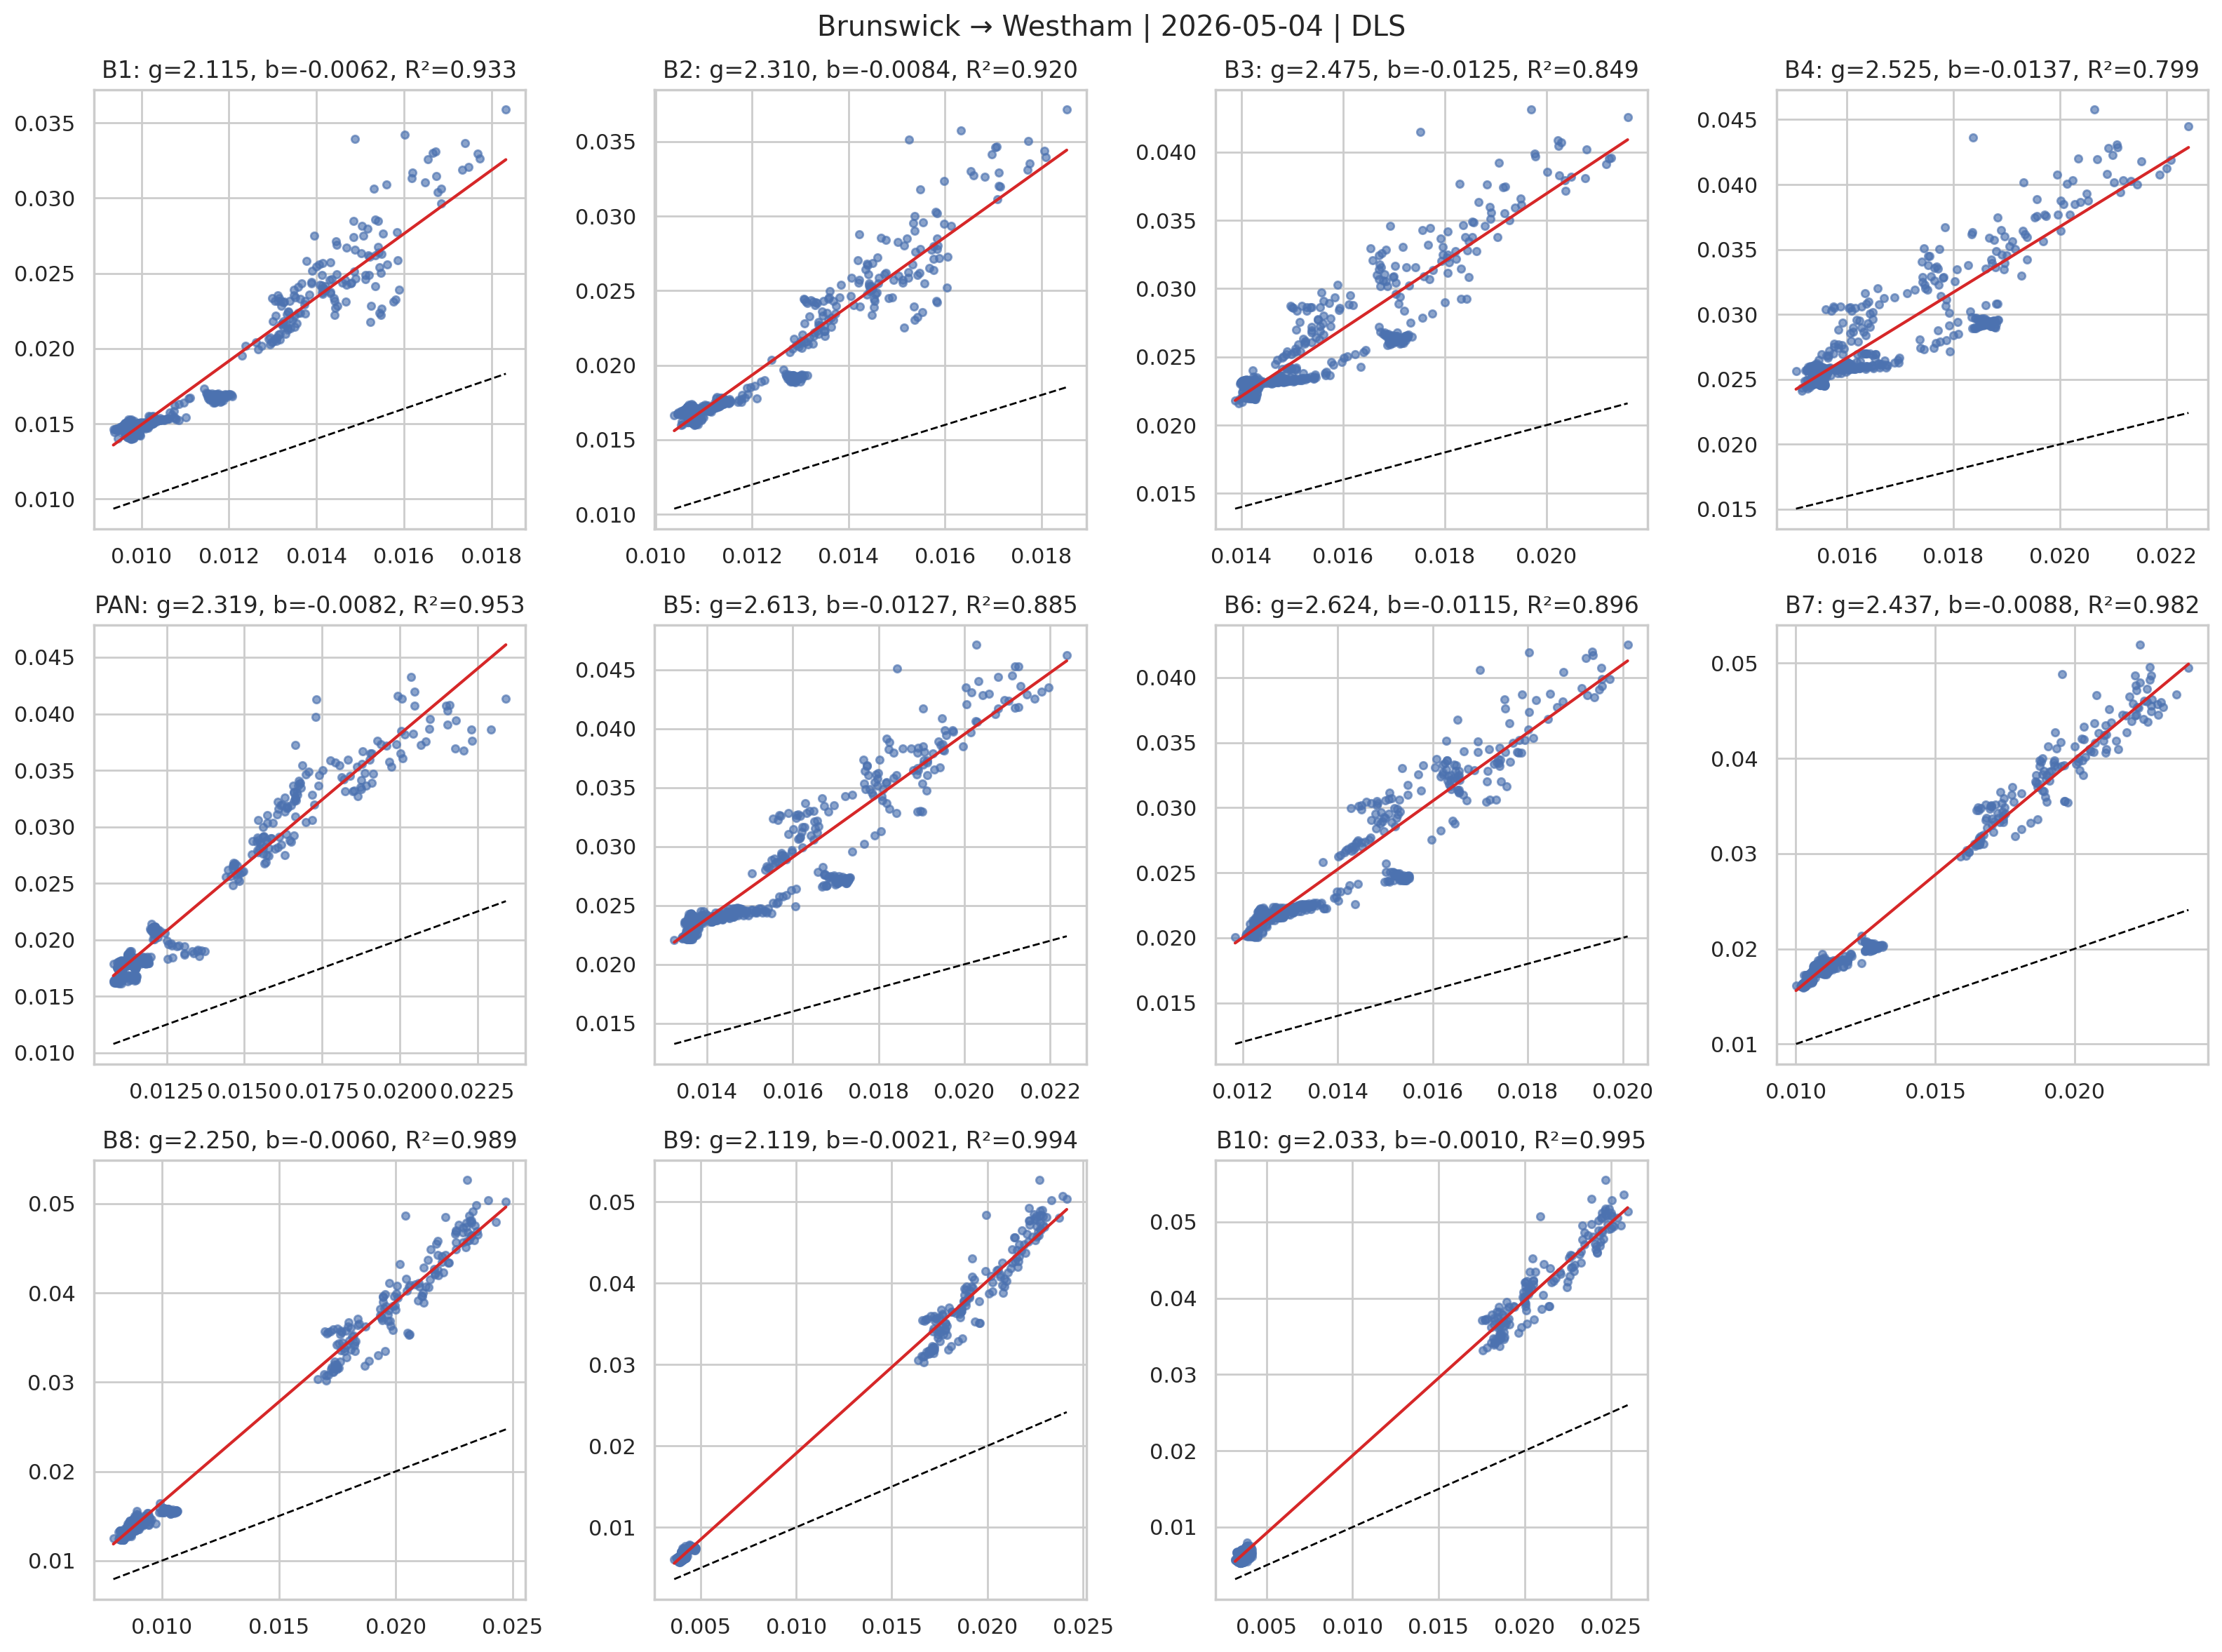

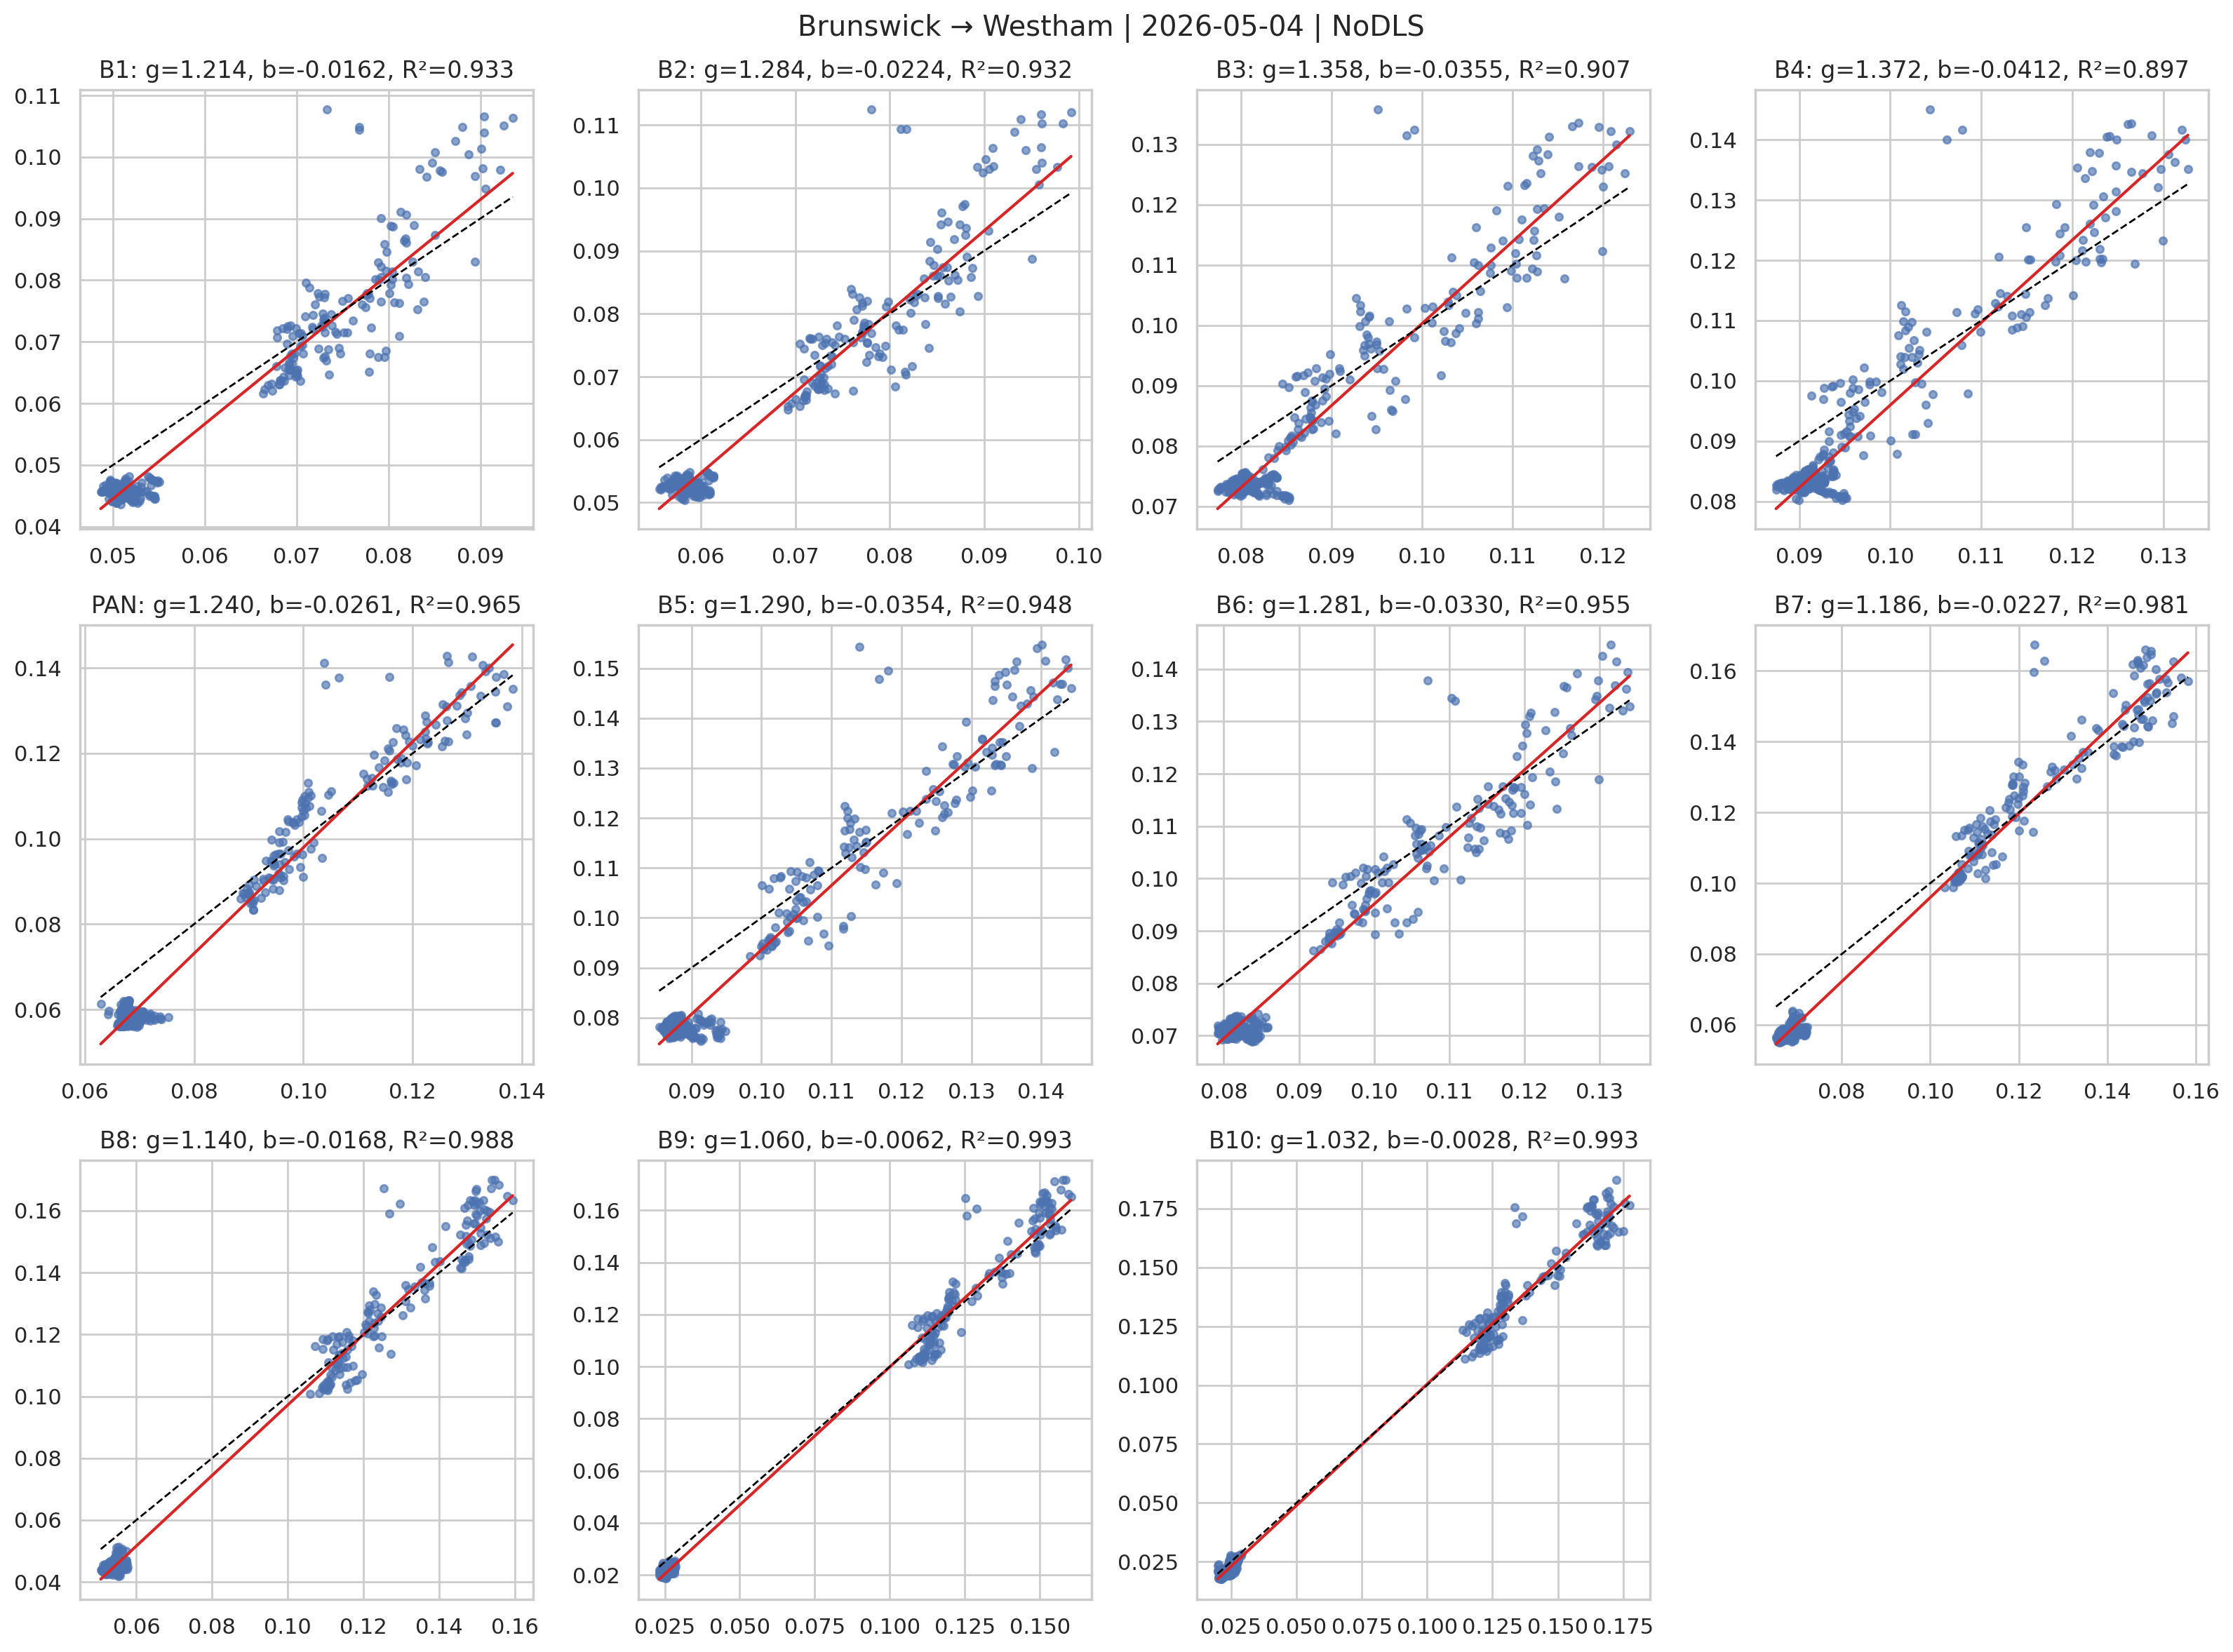

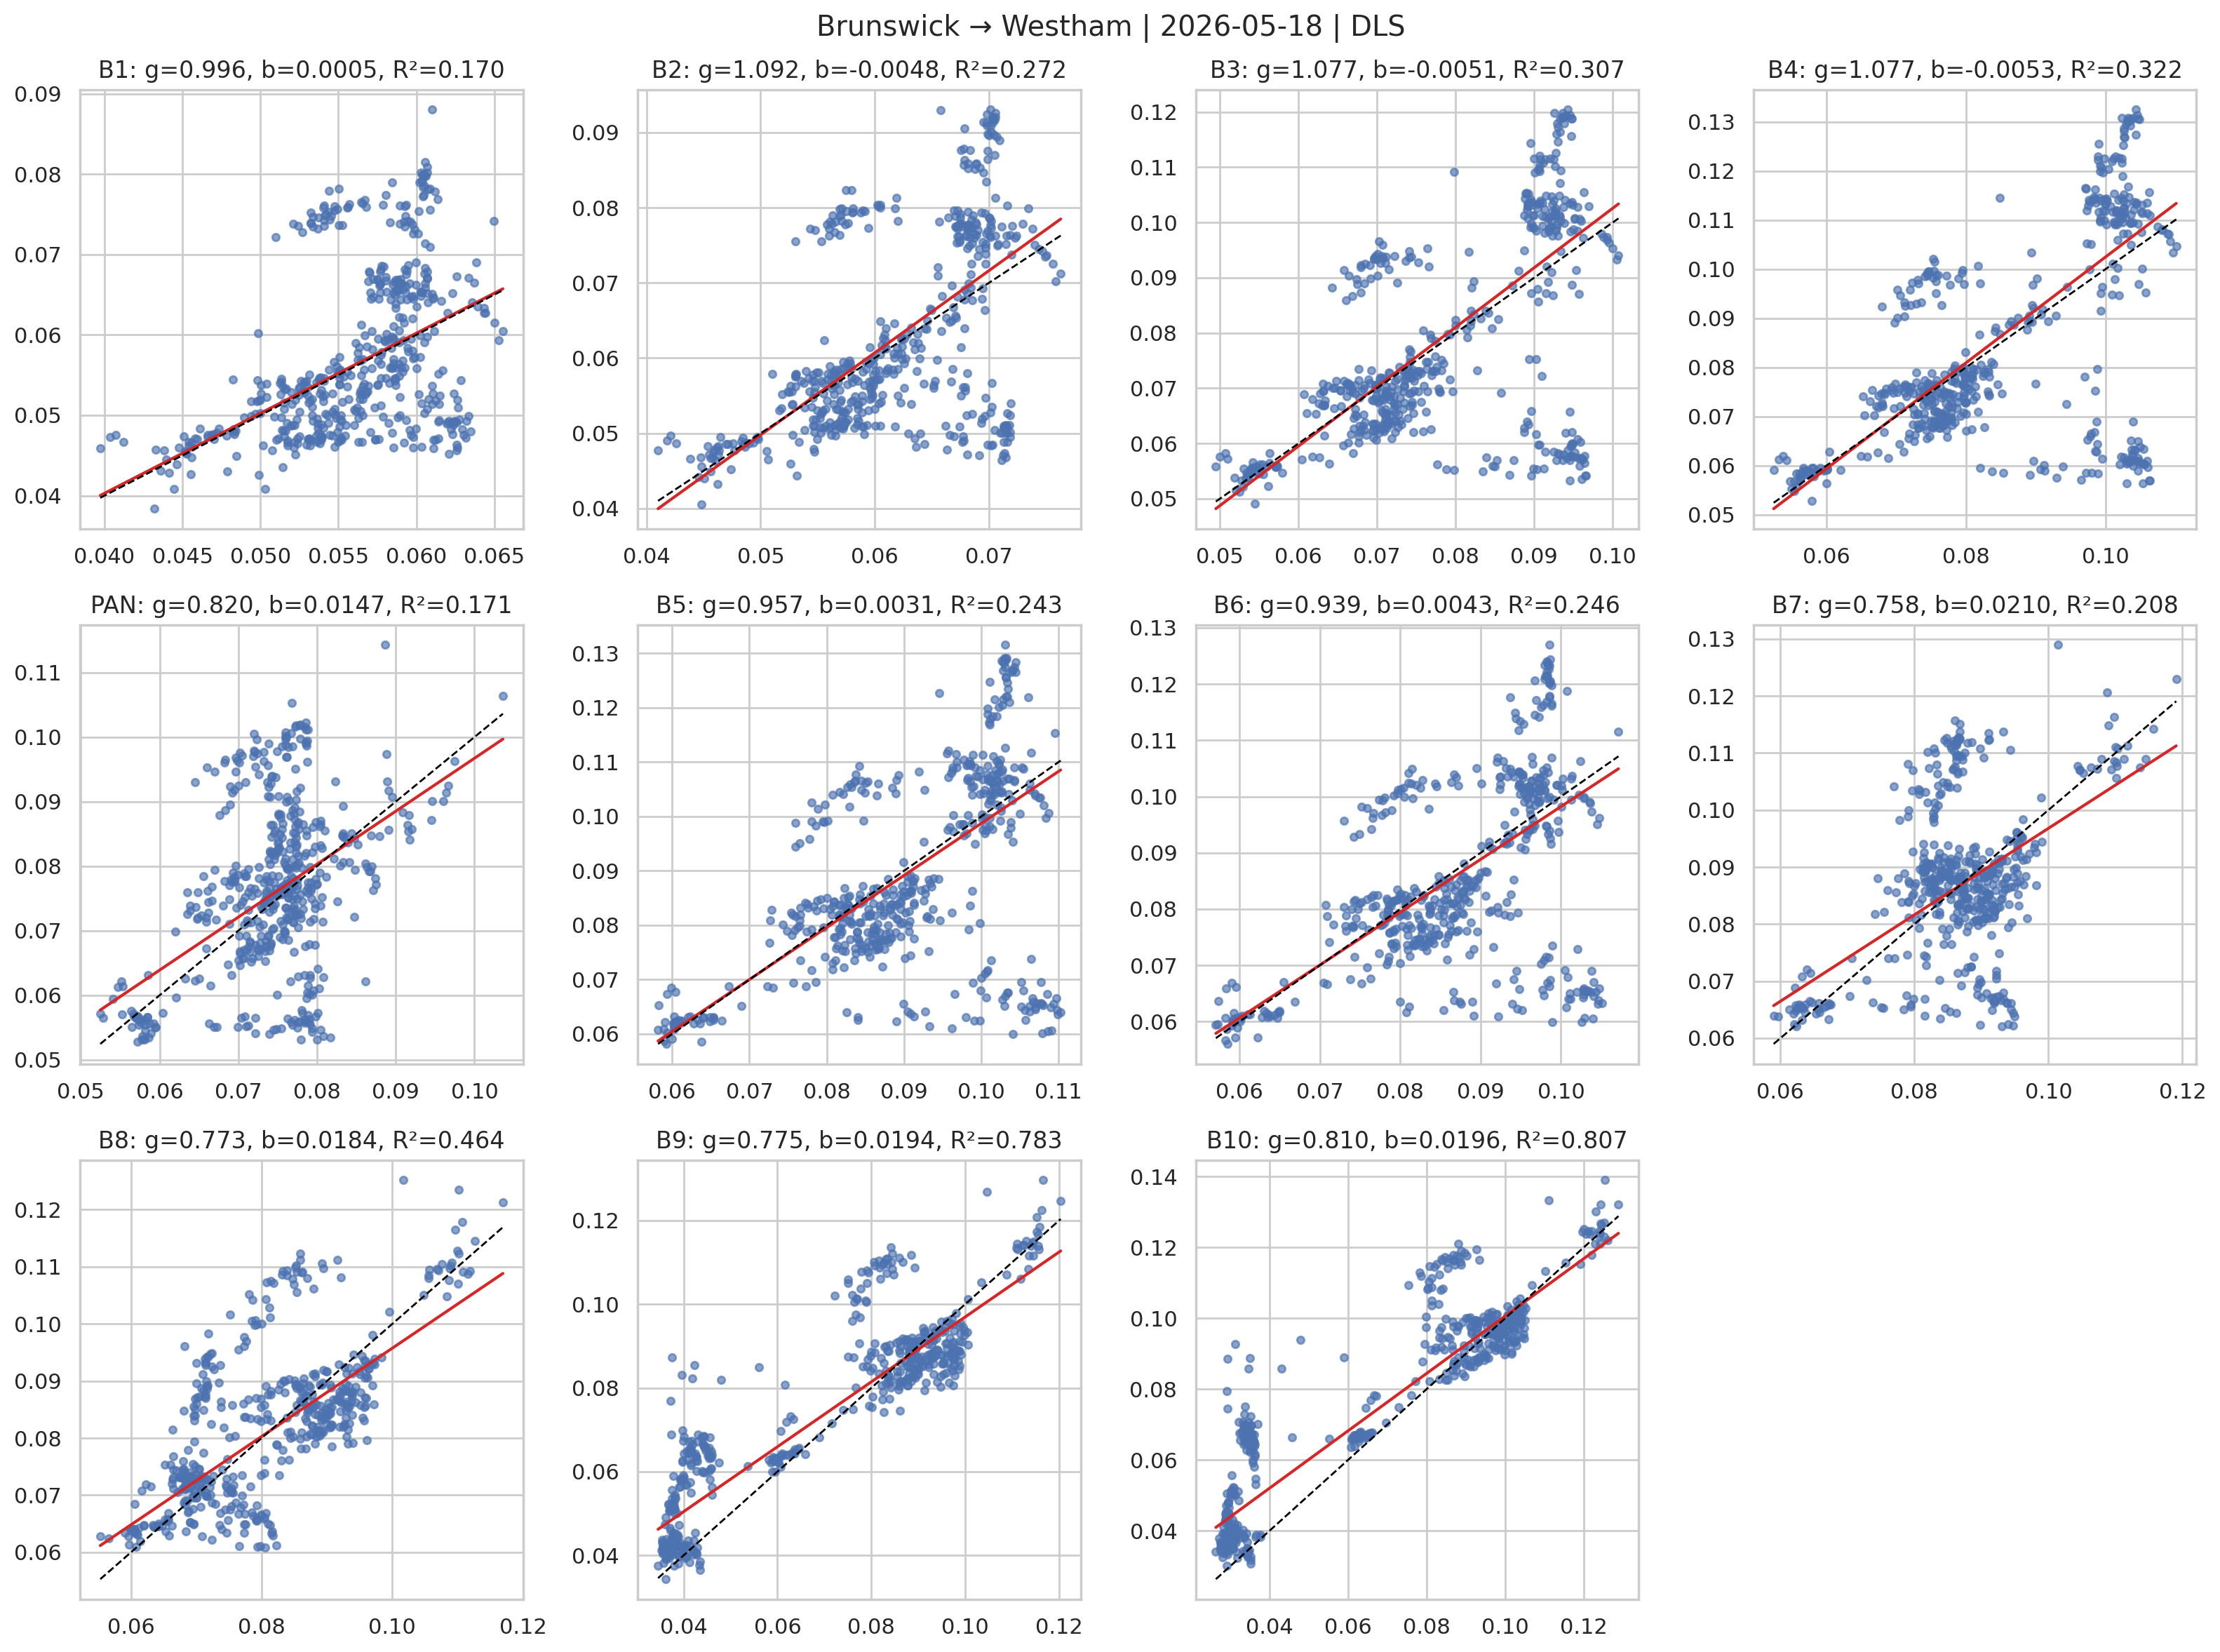

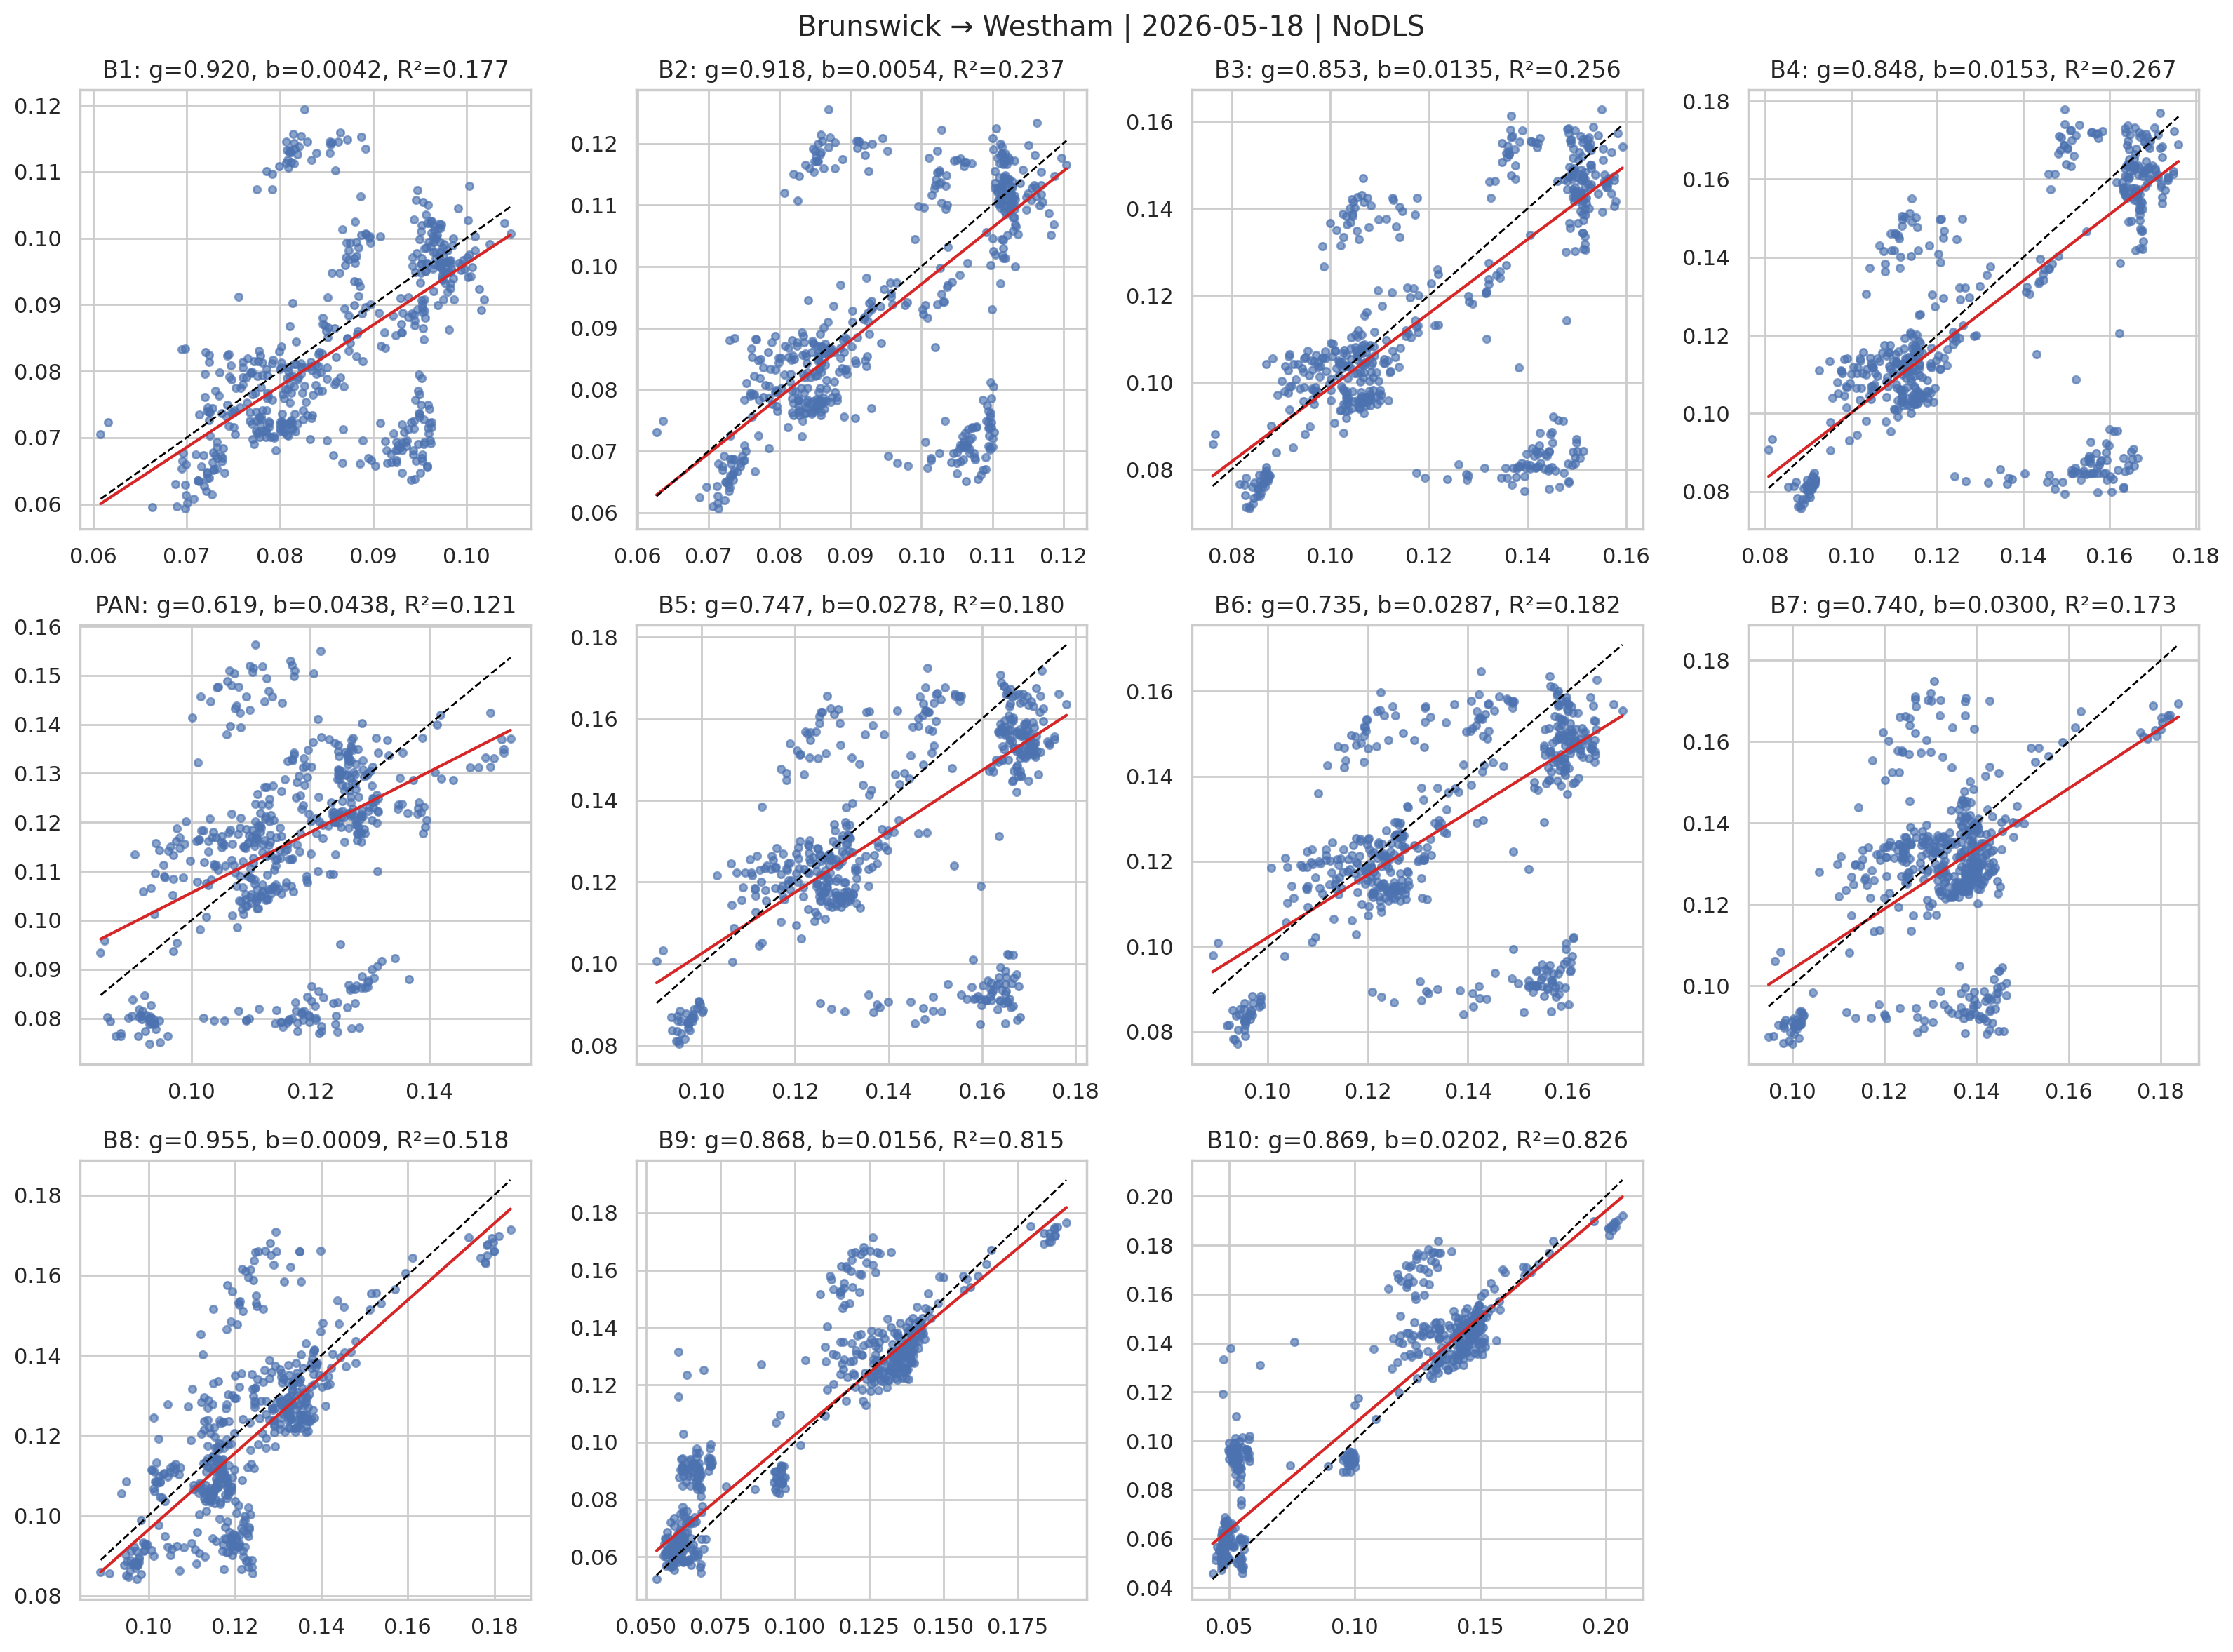

In [14]:
for (
    date,
    dls_mode,
), patches in patch_layers.items():
    coefficients = (
        spatial_coefficients.loc[
            spatial_coefficients[
                "flight_date"
            ].eq(date)
            & spatial_coefficients[
                "dls_mode"
            ].eq(dls_mode)
        ]
    )

    fig, axes = plt.subplots(
        3,
        4,
        figsize=(16, 12),
    )
    axes = axes.ravel()

    for axis, band_name in zip(
        axes,
        SOURCE_BAND_NAMES,
    ):
        x = patches[
            f"br_{band_name}_median"
        ]
        y = patches[
            f"west_{band_name}_median"
        ]
        coefficient = (
            coefficients.loc[
                coefficients[
                    "band_name"
                ].eq(band_name)
            ].iloc[0]
        )

        axis.scatter(
            x,
            y,
            s=14,
            alpha=0.65,
        )
        xx = np.linspace(
            x.min(),
            x.max(),
            100,
        )
        axis.plot(
            xx,
            coefficient["gain"] * xx
            + coefficient["offset"],
            color="tab:red",
        )
        axis.plot(
            xx,
            xx,
            color="black",
            linestyle="--",
            linewidth=1,
        )
        axis.set_title(
            f"{band_name}: "
            f"g={coefficient['gain']:.3f}, "
            f"b={coefficient['offset']:.4f}, "
            f"R²={coefficient['r2']:.3f}"
        )

    axes[-1].axis("off")
    fig.suptitle(
        f"Brunswick → Westham | "
        f"{date} | {dls_mode}"
    )
    fig.tight_layout()

    if SAVE_OUTPUTS:
        stem = (
            f"{date}_{dls_mode}"
            .replace("-", "")
        )
        fig.savefig(
            OUTPUT_DIR
            / f"{stem}_spatial_fit_QA.png",
            dpi=180,
            bbox_inches="tight",
        )
    plt.show()